In [ ]:
# Install required packages
!pip install -q kagglehub tensorflow scikit-learn

In [ ]:
import os
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

import kagglehub

warnings.filterwarnings("ignore")

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [ ]:
from kagglehub import dataset_download

dataset_path = dataset_download(
    "alessandrasala79/ai-vs-human-generated-dataset"
)

print(dataset_path)


Using Colab cache for faster access to the 'ai-vs-human-generated-dataset' dataset.
/kaggle/input/ai-vs-human-generated-dataset


In [ ]:
train_df = pd.read_csv(
    os.path.join(dataset_path, "train.csv")
)

test_df = pd.read_csv(
    os.path.join(dataset_path, "test.csv")
)

print(train_df.head())

print()

print(train_df.shape)

print(test_df.shape)

   Unnamed: 0                                        file_name  label
0           0  train_data/a6dcb93f596a43249135678dfcfc17ea.jpg      1
1           1  train_data/041be3153810433ab146bc97d5af505c.jpg      0
2           2  train_data/615df26ce9494e5db2f70e57ce7a3a4f.jpg      1
3           3  train_data/8542fe161d9147be8e835e50c0de39cd.jpg      0
4           4  train_data/5d81fa12bc3b4cea8c94a6700a477cf2.jpg      1

(79950, 3)
(5540, 1)


In [ ]:
train_df = (
    train_df
    .groupby("label", group_keys=False)
    .apply(lambda x: x.sample(n=15000, random_state=42))
    .reset_index(drop=True)
)

print(train_df.shape)
print(train_df["label"].value_counts())

(30000, 3)
label
0    15000
1    15000
Name: count, dtype: int64


In [ ]:
train_df["file_name"] = train_df["file_name"].apply(
    lambda x: os.path.join(dataset_path, x)
)

train_df.head()

,Unnamed: 0,file_name,label
0,8187,/kaggle/input/ai-vs-human-generated-dataset/tr...,0
1,5703,/kaggle/input/ai-vs-human-generated-dataset/tr...,0
2,70209,/kaggle/input/ai-vs-human-generated-dataset/tr...,0
3,38909,/kaggle/input/ai-vs-human-generated-dataset/tr...,0
4,58065,/kaggle/input/ai-vs-human-generated-dataset/tr...,0


In [ ]:
missing = train_df["file_name"].apply(
    lambda x: not os.path.exists(x)
).sum()

print("Missing Images:", missing)

Missing Images: 0


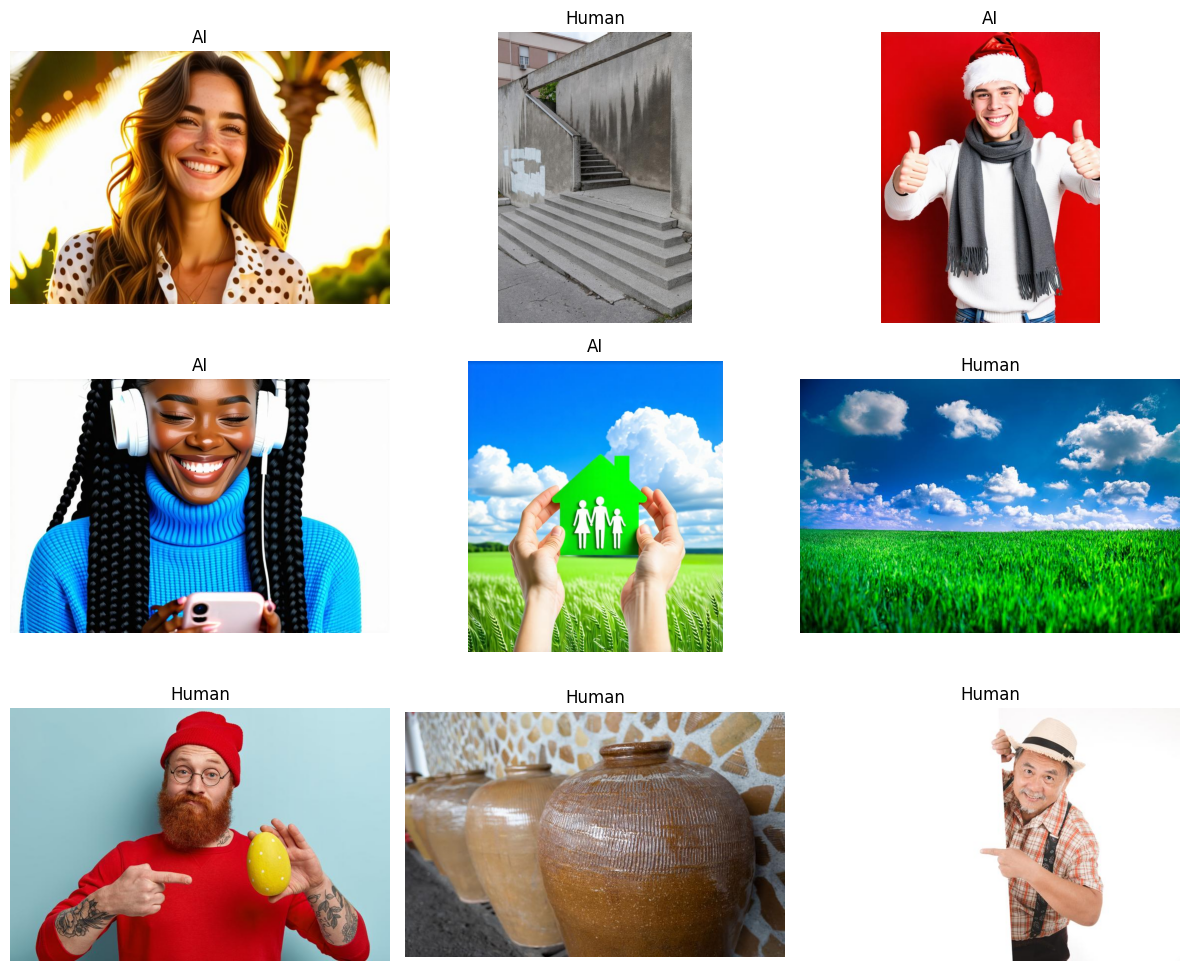

In [ ]:
plt.figure(figsize=(12,10))

sample = train_df.sample(9)

for i,(idx,row) in enumerate(sample.iterrows()):

    img = plt.imread(row["file_name"])

    plt.subplot(3,3,i+1)

    plt.imshow(img)

    plt.title("AI" if row["label"]==1 else "Human")

    plt.axis("off")

plt.tight_layout()

plt.show()

In [ ]:
train_data, val_data = train_test_split(

    train_df,

    test_size=0.20,

    random_state=42,

    stratify=train_df["label"]

)

print("Training Images :", len(train_data))

print("Validation Images :", len(val_data))

print("Training Images :", len(train_data))
print("Validation Images :", len(val_data))

Training Images : 24000
Validation Images : 6000
Training Images : 24000
Validation Images : 6000


In [ ]:
IMG_SIZE = 224

BATCH_SIZE = 8

AUTOTUNE = tf.data.AUTOTUNE

In [ ]:
def load_image(image_path, label):

    image = tf.io.read_file(image_path)

    image = tf.image.decode_jpeg(image, channels=3)

    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))

    image = tf.cast(image, tf.float32)

    return image, label

In [ ]:
train_dataset = tf.data.Dataset.from_tensor_slices(
    (
        train_data["file_name"].values,
        train_data["label"].values
    )
)

val_dataset = tf.data.Dataset.from_tensor_slices(
    (
        val_data["file_name"].values,
        val_data["label"].values
    )
)

In [ ]:
train_dataset = train_dataset.map(
    load_image,
    num_parallel_calls=AUTOTUNE
)

val_dataset = val_dataset.map(
    load_image,
    num_parallel_calls=AUTOTUNE
)

In [ ]:
train_dataset = (
    train_dataset
    .shuffle(1000)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_dataset = (
    val_dataset
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

In [ ]:
for images, labels in train_dataset.take(1):

    print("Image Batch Shape :", images.shape)

    print("Label Batch Shape :", labels.shape)

Image Batch Shape : (8, 224, 224, 3)
Label Batch Shape : (8,)


In [ ]:
data_augmentation = tf.keras.Sequential([

    tf.keras.layers.RandomFlip("horizontal"),

    tf.keras.layers.RandomRotation(0.15),

    tf.keras.layers.RandomZoom(0.15),

    tf.keras.layers.RandomContrast(0.15),

    tf.keras.layers.RandomBrightness(0.15)

])

In [ ]:
base_model = tf.keras.applications.EfficientNetB0(

    include_top=False,

    weights="imagenet",

    input_shape=(IMG_SIZE, IMG_SIZE, 3)

)

In [ ]:
base_model.trainable = False

In [ ]:
inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

x = data_augmentation(inputs)

x = tf.keras.applications.efficientnet.preprocess_input(x)

x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.BatchNormalization()(x)

x = tf.keras.layers.Dropout(0.4)(x)

x = tf.keras.layers.Dense(
    256,
    activation="relu"
)(x)

x = tf.keras.layers.Dropout(0.3)(x)

outputs = tf.keras.layers.Dense(
    1,
    activation="sigmoid"
)(x)

model = tf.keras.Model(inputs, outputs)

In [ ]:
model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="binary_crossentropy",

    metrics=[

        "accuracy",

        tf.keras.metrics.Precision(name="precision"),

        tf.keras.metrics.Recall(name="recall"),

        tf.keras.metrics.AUC(name="auc")

    ]

)

In [ ]:
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_2 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,382,884 (16.72 MB)

 Trainable params: 330,753 (1.26 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(

    monitor="val_loss",

    patience=5,

    restore_best_weights=True

)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.2,

    patience=2,

    verbose=1

)

checkpoint = tf.keras.callbacks.ModelCheckpoint(

    "best_model.keras",

    monitor="val_accuracy",

    save_best_only=True,

    mode="max",

    verbose=1

)

In [ ]:
EPOCHS = 15

history = model.fit(

    train_dataset,

    validation_data=val_dataset,

    epochs=EPOCHS,

    callbacks=[

        early_stop,

        reduce_lr,

        checkpoint

    ]

)

Epoch 1/15
2999/3000 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.7957 - auc: 0.8792 - loss: 0.4964 - precision: 0.7929 - recall: 0.7967
Epoch 1: val_accuracy improved from None to 0.91117, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 148s 44ms/step - accuracy: 0.8181 - auc: 0.8992 - loss: 0.4216 - precision: 0.8180 - recall: 0.8183 - val_accuracy: 0.9112 - val_auc: 0.9708 - val_loss: 0.2255 - val_precision: 0.9048 - val_recall: 0.9190 - learning_rate: 0.0010
Epoch 2/15
2999/3000 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8516 - auc: 0.9301 - loss: 0.3392 - precision: 0.8526 - recall: 0.8478
Epoch 2: val_accuracy did not improve from 0.91117
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 122s 40ms/step - accuracy: 0.8486 - auc: 0.9277 - loss: 0.3449 - precision: 0.8498 - recall: 0.8470 - val_accuracy: 0.9042 - val_auc: 0.9714 - val_loss: 0.2356 - val_precision: 0.8771 - val_recall: 0.9400 - learning_rate: 0.0010
Epoch 3/15


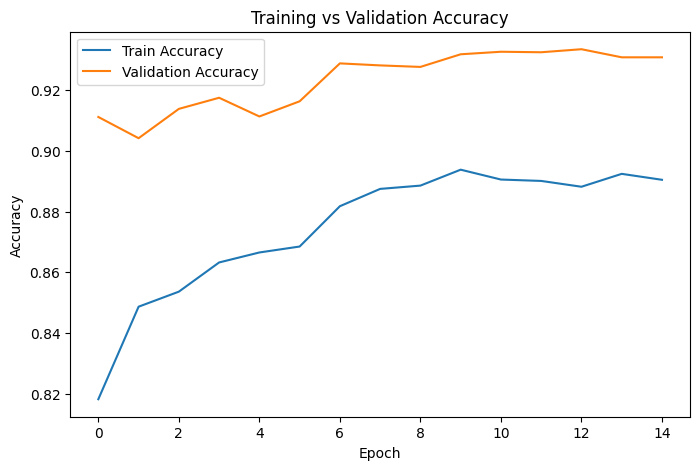

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()

plt.show()

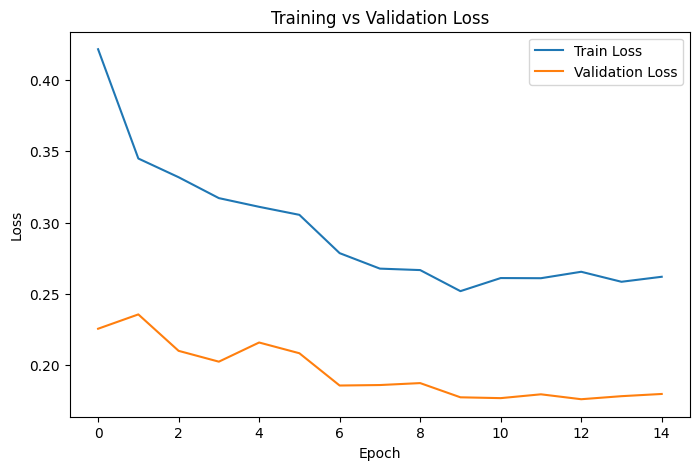

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()

plt.show()

In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-50]:
    layer.trainable = False

In [ ]:
model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),

    loss="binary_crossentropy",

    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

In [ ]:
fine_history = model.fit(

    train_dataset,

    validation_data=val_dataset,

    epochs=5,

    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]

)

Epoch 1/5
2999/3000 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.8694 - auc: 0.9399 - loss: 0.3169 - precision: 0.8711 - recall: 0.8646
Epoch 1: val_accuracy did not improve from 0.93350
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 208s 62ms/step - accuracy: 0.8743 - auc: 0.9451 - loss: 0.3025 - precision: 0.8756 - recall: 0.8725 - val_accuracy: 0.9198 - val_auc: 0.9774 - val_loss: 0.2144 - val_precision: 0.8872 - val_recall: 0.9620 - learning_rate: 1.0000e-05
Epoch 2/5
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.8907 - auc: 0.9582 - loss: 0.2638 - precision: 0.8877 - recall: 0.8918
Epoch 2: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.

Epoch 2: val_accuracy did not improve from 0.93350
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 164s 54ms/step - accuracy: 0.8932 - auc: 0.9596 - loss: 0.2590 - precision: 0.8905 - recall: 0.8966 - val_accuracy: 0.9305 - val_auc: 0.9827 - val_loss: 0.1850 - val_precision: 0.9035 - val_recall: 0.9640 - learning_rate: 1.0000e-05
Epoch 3/5
2999

In [ ]:
model = tf.keras.models.load_model("best_model.keras")

In [ ]:
loss, accuracy, precision, recall, auc_score = model.evaluate(val_dataset)

print(f"Loss      : {loss:.4f}")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"AUC       : {auc_score:.4f}")

750/750 ━━━━━━━━━━━━━━━━━━━━ 28s 27ms/step - accuracy: 0.9335 - auc: 0.9822 - loss: 0.1761 - precision: 0.9197 - recall: 0.9500
Loss      : 0.1761
Accuracy  : 0.9335
Precision : 0.9197
Recall    : 0.9500
AUC       : 0.9822


In [ ]:
y_true = []
y_pred = []
probabilities = []

for images, labels in val_dataset:

    preds = model.predict(images, verbose=0)

    probabilities.extend(preds.flatten())

    preds = (preds > 0.5).astype(int)

    y_true.extend(labels.numpy())
    y_pred.extend(preds.flatten())

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.92      0.93      3000
           1       0.92      0.95      0.93      3000

    accuracy                           0.93      6000
   macro avg       0.93      0.93      0.93      6000
weighted avg       0.93      0.93      0.93      6000



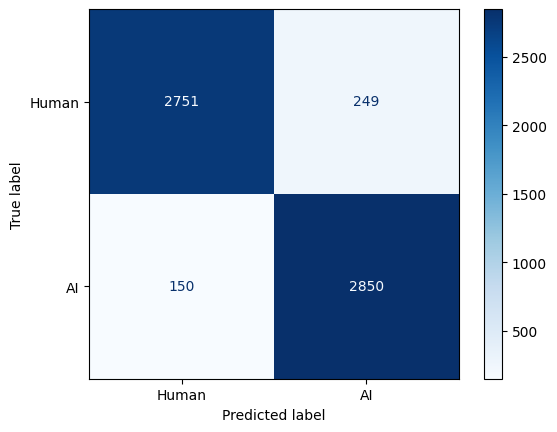

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Human","AI"]
)

disp.plot(cmap="Blues")

plt.show()

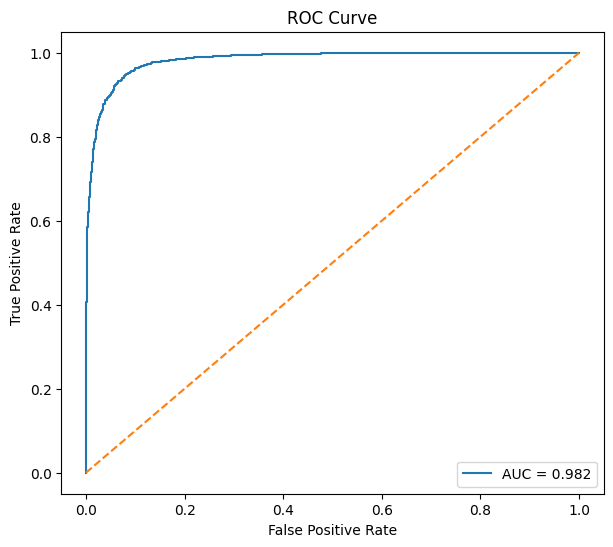

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_true, probabilities)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [ ]:
model.save("AI_vs_Human_EfficientNet_Final.keras")

print("Model Saved Successfully!")

Model Saved Successfully!


In [ ]:
model = tf.keras.models.load_model("best_model.keras")

Saving images (2).jfif to images (2).jfif


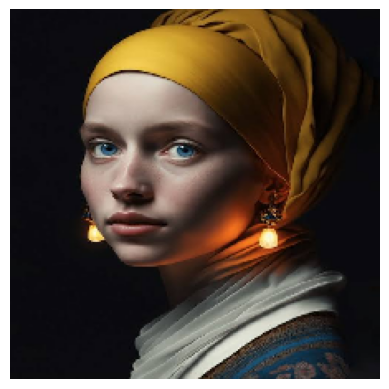

Prediction Probability: 0.8966884
Prediction: AI Generated Image


In [ ]:
from google.colab import files
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

uploaded = files.upload()

image_path = list(uploaded.keys())[0]

img = tf.keras.preprocessing.image.load_img(
    image_path,
    target_size=(IMG_SIZE, IMG_SIZE)
)

plt.imshow(img)
plt.axis("off")
plt.show()

img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array, verbose=0)

print("Prediction Probability:", prediction[0][0])

if prediction[0][0] >= 0.5:
    print("Prediction: AI Generated Image")
else:
    print("Prediction: Human Image")